# Group Relative Policy Optimization (GRPO)

**Notebook 8 of 10** | LLM Alignment Series

## What is GRPO?

**Group Relative Policy Optimization** was introduced by DeepSeek in their [DeepSeek-Math](https://arxiv.org/abs/2402.03300) and [DeepSeek-R1](https://arxiv.org/abs/2501.12948) papers. It simplifies RLHF by eliminating two major components:

1. **No value model** — PPO requires a value head to estimate advantages. GRPO computes advantages by sampling a *group* of completions per prompt and normalizing rewards within each group.
2. **No pre-trained reward model required** — While you *can* use a learned reward model, GRPO works naturally with rule-based reward functions (format checking, correctness verification, length penalties, etc.).

This makes GRPO significantly more memory-efficient and simpler to implement than PPO, while achieving comparable or better results.

## How It Works

For each prompt $x$:

1. **Sample a group** of $G$ completions $\{y_1, y_2, \ldots, y_G\}$ from the current policy $\pi_\theta$
2. **Score each completion** using one or more reward functions $R(x, y_i)$
3. **Normalize rewards within the group** to get advantages:
   $$\hat{A}_i = \frac{R(x, y_i) - \text{mean}(\{R(x, y_j)\}_{j=1}^G)}{\text{std}(\{R(x, y_j)\}_{j=1}^G)}$$
4. **Update the policy** using a clipped objective (similar to PPO). An optional KL penalty (`beta > 0`) keeps the policy close to a frozen reference model.

The key insight: by comparing completions *within a group* for the same prompt, we get a strong relative signal without needing absolute reward calibration or a value baseline.

### GRPO vs PPO vs DPO

| | PPO | DPO | GRPO (β=0) | GRPO (β>0) |
|---|---|---|---|---|
| Reward model | Required (pre-trained) | Not needed | Optional | Optional |
| Value model | Required | Not needed | Not needed | Not needed |
| Reference model | Required | Required | **Not needed** | Required |
| Training data | Prompts only | Preference pairs | Prompts only | Prompts only |
| VRAM usage | High (4 models) | Medium (2 models) | **Low (1 model)** | Medium (2 models) |
| Reward flexibility | Scalar from RM | Implicit | Any function | Any function |
| Advantage estimation | GAE with value model | N/A | Group normalization | Group normalization |

We use **β=0** in this notebook to maximise VRAM headroom on the 4090.

**Model**: Qwen2.5-7B-Instruct | **GPU**: NVIDIA RTX 4090

## Setup

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import re
import gc

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from trl import GRPOConfig, GRPOTrainer
from peft import LoraConfig
from datasets import Dataset

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM: {vram_gb:.1f} GB")

# 5.0s

PyTorch version: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
VRAM: 23.6 GB


## Reward Functions

One of GRPO's biggest advantages is that reward functions can be **anything callable** — no need to train a separate reward model. This is especially powerful for tasks where correctness can be verified programmatically.

We will define several reward functions that each capture a different aspect of response quality:

1. **Format reward** — Does the response follow a structured format?
2. **Conciseness reward** — Is the response appropriately concise (not overly verbose)?
3. **Accuracy reward** — For math/factual questions, is the answer correct?
4. **Helpfulness reward** — Does the response actually address the question?

Each reward function receives a list of prompts and a list of completions, and returns a list of scalar rewards.

In [2]:
def format_reward_func(completions, **kwargs):
    """Reward responses that use structured formatting.

    Checks for numbered lists, bullet points, or clear paragraph structure.
    Returns higher reward for well-structured responses.
    """
    rewards = []
    for completion in completions:
        text = completion[0]["content"] if isinstance(completion, list) else completion
        score = 0.0

        # Reward numbered lists
        if re.search(r'\d+\.\s', text):
            score += 0.5

        # Reward bullet points
        if re.search(r'[-*]\s', text):
            score += 0.3

        # Reward paragraph breaks (indicates structure)
        if text.count('\n\n') >= 1:
            score += 0.2

        rewards.append(score)
    return rewards


def conciseness_reward_func(completions, **kwargs):
    """Reward concise but substantive responses.

    Penalizes both too-short (< 20 words) and too-long (> 300 words) responses.
    Sweet spot is 50-200 words.
    """
    rewards = []
    for completion in completions:
        text = completion[0]["content"] if isinstance(completion, list) else completion
        word_count = len(text.split())

        if word_count < 10:
            score = -1.0  # Too short, probably unhelpful
        elif word_count < 20:
            score = -0.5
        elif word_count <= 200:
            score = 1.0   # Sweet spot
        elif word_count <= 300:
            score = 0.5   # Getting verbose
        else:
            score = 0.0   # Too verbose

        rewards.append(score)
    return rewards


def no_repetition_reward_func(completions, **kwargs):
    """Penalize repetitive text.

    Checks for repeated sentences or phrases, which is a common failure mode.
    """
    rewards = []
    for completion in completions:
        text = completion[0]["content"] if isinstance(completion, list) else completion
        sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]

        if len(sentences) <= 1:
            rewards.append(0.0)
            continue

        # Check for duplicate sentences
        unique_ratio = len(set(sentences)) / len(sentences)
        score = unique_ratio  # 1.0 = all unique, lower = more repetition

        rewards.append(score)
    return rewards


def helpfulness_reward_func(prompts, completions, **kwargs):
    """Reward responses that appear to address the prompt.

    Simple heuristic: check if key words from the prompt appear in the response,
    and that the response doesn't start with a refusal.
    """
    rewards = []
    refusal_starts = [
        "i can't", "i cannot", "i'm sorry", "sorry,", "i apologize",
        "as an ai", "i'm not able",
    ]

    for prompt, completion in zip(prompts, completions):
        text = completion[0]["content"] if isinstance(completion, list) else completion
        prompt_text = prompt[0]["content"] if isinstance(prompt, list) else prompt
        text_lower = text.lower().strip()

        # Penalize refusals on non-harmful prompts
        if any(text_lower.startswith(r) for r in refusal_starts):
            rewards.append(-0.5)
            continue

        # Check keyword overlap between prompt and response
        prompt_words = set(prompt_text.lower().split()) - {
            'the', 'a', 'an', 'is', 'are', 'was', 'were', 'what', 'how',
            'why', 'when', 'where', 'who', 'which', 'do', 'does', 'can',
            'could', 'would', 'should', 'in', 'on', 'at', 'to', 'for',
            'of', 'and', 'or', 'but', 'with', 'this', 'that', 'it', 'me',
            'you', 'your', 'my', 'i', 'please', 'explain', 'describe',
        }
        response_words = set(text_lower.split())
        if prompt_words:
            overlap = len(prompt_words & response_words) / len(prompt_words)
        else:
            overlap = 0.5

        score = min(overlap * 2.0, 1.0)  # Cap at 1.0
        rewards.append(score)

    return rewards


# Test the reward functions
test_completions = [
    [[{"content": "1. First point\n2. Second point\n\nIn conclusion, this is well structured."}]],
    [[{"content": "Yes."}]],
    [[{"content": "The answer is complex. " * 20}]],
]

print("Format rewards:", format_reward_func([c[0] for c in test_completions]))
print("Conciseness rewards:", conciseness_reward_func([c[0] for c in test_completions]))
print("Repetition rewards:", no_repetition_reward_func([c[0] for c in test_completions]))

Format rewards: [0.7, 0.0, 0.0]
Conciseness rewards: [-0.5, -1.0, 1.0]
Repetition rewards: [1.0, 0.0, 0.05]


## Prepare Training Prompts

GRPO only needs prompts — no preference pairs, no pre-scored responses. The model generates its own completions and learns from the relative quality within each group.

We create a diverse set of prompts spanning factual questions, reasoning, creative tasks, and instruction-following.

In [3]:
training_prompts = [
    # Factual / Knowledge
    "What causes earthquakes?",
    "Explain how vaccines work.",
    "What is the water cycle?",
    "How does photosynthesis work?",
    "What causes the northern lights?",
    "What is the difference between weather and climate?",
    "How do airplanes fly?",
    "What is the greenhouse effect?",
    "How does the internet work?",
    "What is evolution by natural selection?",
    "How do batteries store energy?",
    "What causes tides?",
    "What is DNA and what does it do?",
    "How do computers process information?",
    "What is inflation in economics?",

    # Reasoning / Analysis
    "What are the pros and cons of remote work?",
    "Compare renewable and non-renewable energy sources.",
    "What are the main causes of deforestation?",
    "Explain why biodiversity is important.",
    "What are the arguments for and against space exploration funding?",
    "How does urbanization affect the environment?",
    "What factors contribute to income inequality?",
    "Compare the advantages of electric cars versus gasoline cars.",
    "What are the ethical implications of genetic engineering?",
    "Why is clean water access a global challenge?",

    # Instruction Following
    "List 5 tips for better sleep. Use a numbered list.",
    "Summarize the benefits of regular exercise in 3 bullet points.",
    "Write a brief explanation of machine learning for a 10-year-old.",
    "Give me a step-by-step guide to making scrambled eggs.",
    "Explain the scientific method in exactly 4 steps.",
    "List 3 ways to reduce your carbon footprint.",
    "Describe the solar system in one paragraph.",
    "Write a brief comparison of cats and dogs as pets.",
    "Explain what a black hole is in simple terms.",
    "Give 3 reasons why reading is beneficial.",

    # Creative
    "Write a haiku about the ocean.",
    "Describe a futuristic city in 3 sentences.",
    "Write a motivational message for someone starting a new job.",
    "Create a short analogy explaining how memory works.",
    "Write a brief product description for a smart water bottle.",

    # Empathy / Advice
    "What advice would you give someone learning to code?",
    "How can someone manage stress effectively?",
    "What should someone consider before adopting a pet?",
    "How can a student improve their study habits?",
    "What are some ways to build self-confidence?",
]

# Format as chat messages for the Qwen chat template
train_data = []
for prompt in training_prompts:
    train_data.append({
        "prompt": [{"role": "user", "content": prompt}],
    })

train_dataset = Dataset.from_list(train_data)
print(f"Training prompts: {len(train_dataset)}")
print(f"\nExample:")
print(train_dataset[0])

Training prompts: 45

Example:
{'prompt': [{'content': 'What causes earthquakes?', 'role': 'user'}]}


## Load the Model

We load Qwen2.5-7B-Instruct with 4-bit quantization and attach LoRA adapters. GRPO is more memory-efficient than PPO because there is no value model — just the policy and a reference copy.

In [ ]:
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

# 4-bit quantization config
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Load model
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# LoRA config
peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    task_type="CAUSAL_LM",
)

print(f"Model loaded: {MODEL_NAME}")
print(f"VRAM allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"VRAM reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

# 8.1s

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen2.5-7B-Instruct
VRAM allocated: 5.20 GB
VRAM reserved: 13.74 GB


## Configure GRPO Training

Key GRPO-specific parameters:

| Parameter | Value | Description |
|---|---|---|
| `num_generations` | 2 | Completions sampled per prompt (the "group" size G). More = better advantage estimates but more VRAM. We use 2 to fit the 7B model on a single 4090. |
| `max_completion_length` | 128 | Maximum tokens per completion. Shorter = less VRAM during generation. |
| `beta` | 0.0 | KL penalty coefficient. **0 = no reference model**, which saves ~5GB VRAM. Set to 0.1+ if you have headroom and want to prevent reward hacking. |
| `epsilon` | 0.2 | PPO-style clipping range for the policy ratio. |
| `num_iterations` | 1 | Number of policy update iterations per batch of generations. |
| `loss_type` | "grpo" | The loss variant to use. |
| `scale_rewards` | "group" | Normalize rewards within each group (the core GRPO idea). |

> **VRAM note**: With `beta=0.0` only the policy model lives in VRAM (no reference copy). With `num_generations=2` and `max_completion_length=128`, the 7B model in 4-bit fits comfortably on a 24GB GPU.

In [5]:
grpo_config = GRPOConfig(
    output_dir="./results/grpo",

    # Training
    num_train_epochs=2,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=5e-6,
    warmup_ratio=0.1,
    bf16=True,
    gradient_checkpointing=True,

    # GRPO-specific
    num_generations=2,           # Group size (G) — 2 completions per prompt (VRAM-efficient for 7B)
    max_completion_length=128,   # Max tokens per completion (shorter = less VRAM)
    temperature=0.8,             # Sampling temperature for generation
    beta=0.0,                    # KL penalty = 0 means NO reference model (saves ~5GB VRAM)
    epsilon=0.2,                 # Clipping range
    num_iterations=1,            # Policy updates per generation batch
    loss_type="grpo",            # GRPO loss
    scale_rewards="group",       # Group-level reward normalization

    # Logging and saving
    logging_steps=1,
    save_strategy="epoch",
    report_to="none",

    # Memory optimization
    torch_empty_cache_steps=1,
)

print("GRPO Configuration:")
print(f"  Group size (num_generations): {grpo_config.num_generations}")
print(f"  Max completion length: {grpo_config.max_completion_length}")
print(f"  Beta (KL penalty): {grpo_config.beta}  <- no reference model")
print(f"  Epsilon (clip range): {grpo_config.epsilon}")
print(f"  Loss type: {grpo_config.loss_type}")
print(f"  Scale rewards: {grpo_config.scale_rewards}")
print(f"  Batch size: {grpo_config.per_device_train_batch_size}")
print(f"  Gradient accumulation: {grpo_config.gradient_accumulation_steps}")
print(f"  Effective batch size: {grpo_config.per_device_train_batch_size * grpo_config.gradient_accumulation_steps}")
print(f"  Completions per effective batch: {grpo_config.per_device_train_batch_size * grpo_config.gradient_accumulation_steps * grpo_config.num_generations}")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


GRPO Configuration:
  Group size (num_generations): 2
  Max completion length: 128
  Beta (KL penalty): 0.0  <- no reference model
  Epsilon (clip range): 0.2
  Loss type: grpo
  Scale rewards: group
  Batch size: 1
  Gradient accumulation: 4
  Effective batch size: 4
  Completions per effective batch: 8


## Create the Trainer

The `GRPOTrainer` takes `reward_funcs` — a list of callable reward functions. Each function is called on every batch of generations, and their outputs are combined (summed by default). This is where GRPO shines: you can mix and match different reward signals without training a monolithic reward model.

In [6]:
trainer = GRPOTrainer(
    model=model,
    reward_funcs=[
        format_reward_func,
        conciseness_reward_func,
        no_repetition_reward_func,
        helpfulness_reward_func,
    ],
    args=grpo_config,
    train_dataset=train_dataset,
    processing_class=tokenizer,
    peft_config=peft_config,
)

print("GRPOTrainer created.")
print(f"Number of reward functions: 4")
print(f"Training samples: {len(train_dataset)}")
print(f"VRAM allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

GRPOTrainer created.
Number of reward functions: 4
Training samples: 45
VRAM allocated: 5.27 GB


## Train

During each step, the trainer will:
1. Sample a batch of prompts
2. Generate `num_generations` (2) completions per prompt
3. Score all completions with each reward function
4. Normalize rewards within each group (group mean subtracted, divided by std)
5. Update the policy using the clipped GRPO objective

With `beta=0.0` there is no KL term and no reference model — the only model in VRAM is the policy.

In [ ]:
print("Starting GRPO training...")
print(f"Peak VRAM before training: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")
print()

train_result = trainer.train()

print(f"\nTraining complete!")
print(f"Peak VRAM during training: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")
print(f"Total steps: {trainer.state.global_step}")

# 8m 15.5s

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting GRPO training...
Peak VRAM before training: 13.62 GB



Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Step,Training Loss
1,0.000000
2,0.000000
3,-0.000000
4,0.000000
5,-0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000
10,0.000000


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='le


Training complete!
Peak VRAM during training: 13.62 GB
Total steps: 44


## Plot Training Metrics

Available metrics: ['loss', 'grad_norm', 'learning_rate', 'num_tokens', 'completions/mean_length', 'completions/min_length', 'completions/max_length', 'completions/clipped_ratio', 'completions/mean_terminated_length', 'completions/min_terminated_length', 'completions/max_terminated_length', 'rewards/format_reward_func/mean', 'rewards/format_reward_func/std', 'rewards/conciseness_reward_func/mean', 'rewards/conciseness_reward_func/std', 'rewards/no_repetition_reward_func/mean', 'rewards/no_repetition_reward_func/std', 'rewards/helpfulness_reward_func/mean', 'rewards/helpfulness_reward_func/std', 'reward', 'reward_std', 'frac_reward_zero_std', 'entropy', 'clip_ratio/low_mean', 'clip_ratio/low_min', 'clip_ratio/high_mean', 'clip_ratio/high_max', 'clip_ratio/region_mean', 'step_time', 'epoch']


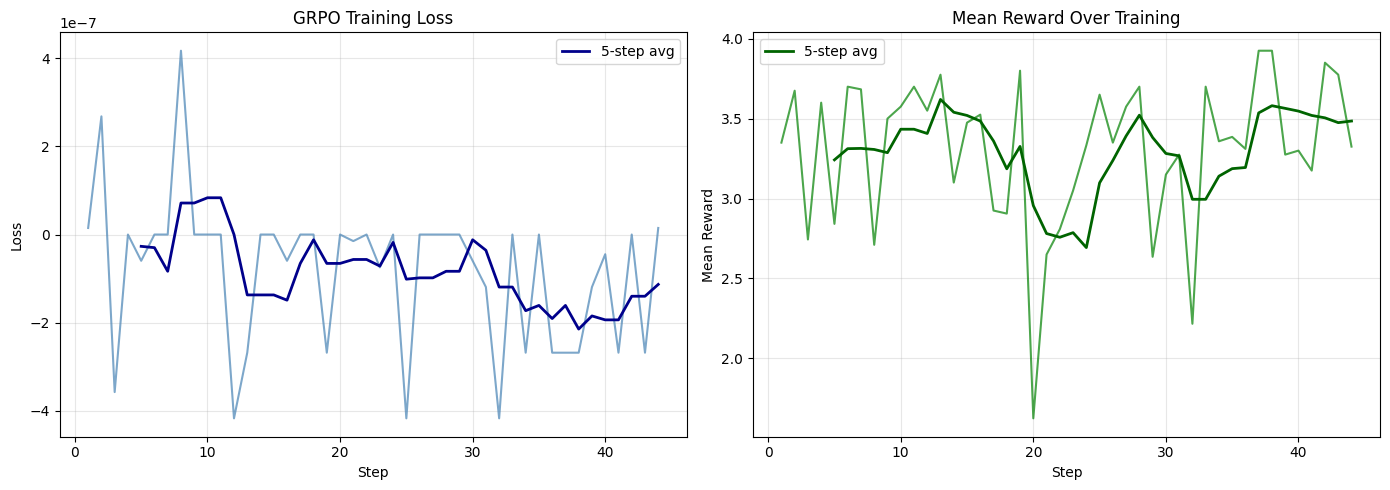

In [8]:
# Extract metrics from training log
log_history = trainer.state.log_history

steps = [entry["step"] for entry in log_history if "loss" in entry]
losses = [entry["loss"] for entry in log_history if "loss" in entry]

# Try to extract reward metrics
reward_keys = [k for k in log_history[0].keys() if "reward" in k.lower()] if log_history else []
print(f"Available metrics: {[k for k in log_history[0].keys() if k != 'step']}" if log_history else "No logs yet")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
if steps and losses:
    axes[0].plot(steps, losses, color="steelblue", alpha=0.7)
    if len(losses) >= 5:
        window = min(5, len(losses))
        rolling = np.convolve(losses, np.ones(window)/window, mode="valid")
        axes[0].plot(steps[window-1:], rolling, color="darkblue", linewidth=2, label=f"{window}-step avg")
        axes[0].legend()
    axes[0].set_xlabel("Step")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("GRPO Training Loss")
    axes[0].grid(True, alpha=0.3)

# Plot rewards if available
reward_steps = [entry["step"] for entry in log_history if "reward" in entry]
reward_vals = [entry["reward"] for entry in log_history if "reward" in entry]

if reward_steps and reward_vals:
    axes[1].plot(reward_steps, reward_vals, color="green", alpha=0.7)
    if len(reward_vals) >= 5:
        window = min(5, len(reward_vals))
        rolling = np.convolve(reward_vals, np.ones(window)/window, mode="valid")
        axes[1].plot(reward_steps[window-1:], rolling, color="darkgreen", linewidth=2, label=f"{window}-step avg")
        axes[1].legend()
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Mean Reward")
    axes[1].set_title("Mean Reward Over Training")
    axes[1].grid(True, alpha=0.3)
else:
    # Plot all available reward-related metrics
    for key in sorted(set().union(*(e.keys() for e in log_history))):
        if "reward" in key.lower() or "score" in key.lower():
            vals = [(e["step"], e[key]) for e in log_history if key in e]
            if vals:
                axes[1].plot([v[0] for v in vals], [v[1] for v in vals], label=key, alpha=0.7)
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Value")
    axes[1].set_title("Reward Metrics")
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Save the Model

In [9]:
trainer.save_model("./results/grpo/final")
tokenizer.save_pretrained("./results/grpo/final")
print("Model saved to ./results/grpo/final")

import os
for f in sorted(os.listdir("./results/grpo/final")):
    size = os.path.getsize(f"./results/grpo/final/{f}") / 1024**2
    print(f"  {f}: {size:.1f} MB")

Model saved to ./results/grpo/final
  README.md: 0.0 MB
  adapter_config.json: 0.0 MB
  adapter_model.safetensors: 77.1 MB
  chat_template.jinja: 0.0 MB
  tokenizer.json: 10.9 MB
  tokenizer_config.json: 0.0 MB
  training_args.bin: 0.0 MB


## Compare: Base Model vs GRPO

Let us generate responses from the GRPO-trained model and compare them with the base model to see if our reward functions had the intended effect.

In [ ]:
def generate_response(model, tokenizer, prompt, max_new_tokens=256):
    """Generate a response using the chat template."""
    messages = [{"role": "user", "content": prompt}]
    formatted = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(formatted, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.7,
            top_p=0.9,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )

    return tokenizer.decode(output[0][input_len:], skip_special_tokens=True)


# Generate from the GRPO model (still loaded as the trainer's model)
grpo_model = trainer.model
grpo_model.eval()

test_prompts = [
    "What are the main causes of climate change?",
    "List 3 benefits of learning a second language.",
    "Explain how a computer virus works.",
    "What advice would you give to someone starting a small business?",
    "Describe the process of making coffee.",
    "What is the difference between AI and machine learning?",
]

grpo_responses = {}
print("Generating GRPO model responses...")
for prompt in test_prompts:
    grpo_responses[prompt] = generate_response(grpo_model, tokenizer, prompt)

print(f"Done. Generated {len(grpo_responses)} responses.")

# 1m 28.3s

Generating GRPO model responses...
Done. Generated 6 responses.


In [ ]:
# Free GRPO model and load the base model for comparison
del grpo_model, trainer
gc.collect()
torch.cuda.empty_cache()

print("Loading base model for comparison...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
base_model.eval()

base_responses = {}
print("Generating base model responses...")
for prompt in test_prompts:
    base_responses[prompt] = generate_response(base_model, tokenizer, prompt)

del base_model
gc.collect()
torch.cuda.empty_cache()
print("Done.")

# 1m 4.4s

Loading base model for comparison...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Generating base model responses...
Done.


In [12]:
# Side-by-side comparison
for prompt in test_prompts:
    print("=" * 80)
    print(f"PROMPT: {prompt}")
    print("=" * 80)

    print("--- Base Model ---")
    print(base_responses[prompt][:500])

    print("--- GRPO Model ---")
    print(grpo_responses[prompt][:500])

    # Score both with our reward functions
    # Each comp is [[{"content": ...}]] so the reward func sees completion=[{"content": ...}]
    base_comp   = [[{"content": base_responses[prompt]}]]
    grpo_comp   = [[{"content": grpo_responses[prompt]}]]
    prompt_msgs = [[{"content": prompt}]]

    base_scores = {
        "format":    format_reward_func(base_comp)[0],
        "concise":   conciseness_reward_func(base_comp)[0],
        "no_repeat": no_repetition_reward_func(base_comp)[0],
        "helpful":   helpfulness_reward_func(prompt_msgs, base_comp)[0],
    }
    grpo_scores = {
        "format":    format_reward_func(grpo_comp)[0],
        "concise":   conciseness_reward_func(grpo_comp)[0],
        "no_repeat": no_repetition_reward_func(grpo_comp)[0],
        "helpful":   helpfulness_reward_func(prompt_msgs, grpo_comp)[0],
    }

    print(f"Reward Scores:")
    print(f"  {'Metric':<12} {'Base':>8} {'GRPO':>8} {'Delta':>8}")
    total_base, total_grpo = 0, 0
    for key in base_scores:
        delta = grpo_scores[key] - base_scores[key]
        sign = "+" if delta > 0 else ""
        print(f"  {key:<12} {base_scores[key]:>8.2f} {grpo_scores[key]:>8.2f} {sign}{delta:>7.2f}")
        total_base += base_scores[key]
        total_grpo += grpo_scores[key]
    delta = total_grpo - total_base
    sign = "+" if delta > 0 else ""
    print(f"  {'TOTAL':<12} {total_base:>8.2f} {total_grpo:>8.2f} {sign}{delta:>7.2f}")
    print()


PROMPT: What are the main causes of climate change?
--- Base Model ---
The primary causes of climate change can be attributed to both natural and human factors, but the overwhelming scientific consensus is that human activities are the dominant cause of recent climate change. Here are the main anthropogenic (human-caused) factors:

1. **Greenhouse Gas Emissions**: The most significant greenhouse gases contributing to global warming are carbon dioxide (CO2), methane (CH4), nitrous oxide (N2O), and fluorinated gases. Human activities like burning fossil fuels for ene
--- GRPO Model ---
Climate change is primarily caused by a variety of factors, but human activities have significantly contributed to the current rate and extent of global warming over recent decades. Here are the main causes:

1. **Greenhouse Gas Emissions**: The burning of fossil fuels (coal, oil, and gas) for energy, transportation, and industrial processes releases large amounts of carbon dioxide (CO2), methane (CH4), ni

## Reward Score Analysis

   Metric  Base  GRPO  Delta
   format 0.800 0.800  0.000
  concise 1.000 0.750 -0.250
no_repeat 1.000 1.000  0.000
  helpful 0.967 0.911 -0.056
    TOTAL 3.767 3.461 -0.306


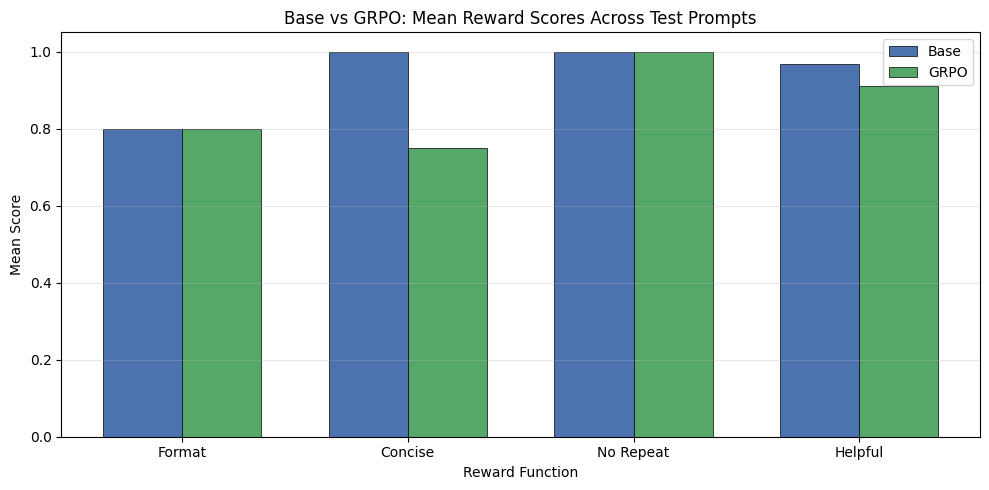

In [13]:
import pandas as pd

# Aggregate scores across all test prompts
metrics = ["format", "concise", "no_repeat", "helpful"]
summary = {"Metric": [], "Base": [], "GRPO": []}

for metric in metrics:
    base_vals = []
    grpo_vals = []
    for prompt in test_prompts:
        base_comp = [[{"content": base_responses[prompt]}]]
        grpo_comp = [[{"content": grpo_responses[prompt]}]]
        prompt_msgs = [[{"content": prompt}]]

        if metric == "format":
            base_vals.append(format_reward_func(base_comp)[0])
            grpo_vals.append(format_reward_func(grpo_comp)[0])
        elif metric == "concise":
            base_vals.append(conciseness_reward_func(base_comp)[0])
            grpo_vals.append(conciseness_reward_func(grpo_comp)[0])
        elif metric == "no_repeat":
            base_vals.append(no_repetition_reward_func(base_comp)[0])
            grpo_vals.append(no_repetition_reward_func(grpo_comp)[0])
        elif metric == "helpful":
            base_vals.append(helpfulness_reward_func(prompt_msgs, base_comp)[0])
            grpo_vals.append(helpfulness_reward_func(prompt_msgs, grpo_comp)[0])

    summary["Metric"].append(metric)
    summary["Base"].append(np.mean(base_vals))
    summary["GRPO"].append(np.mean(grpo_vals))

# Add total
summary["Metric"].append("TOTAL")
summary["Base"].append(sum(summary["Base"]))
summary["GRPO"].append(sum(summary["GRPO"]))

df = pd.DataFrame(summary)
df["Delta"] = df["GRPO"] - df["Base"]
print(df.to_string(index=False, float_format="{:.3f}".format))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, df["Base"].values[:-1], width, label="Base", color="#4C72B0", edgecolor="black", linewidth=0.5)
bars2 = ax.bar(x + width/2, df["GRPO"].values[:-1], width, label="GRPO", color="#55A868", edgecolor="black", linewidth=0.5)

ax.set_xlabel("Reward Function")
ax.set_ylabel("Mean Score")
ax.set_title("Base vs GRPO: Mean Reward Scores Across Test Prompts")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ").title() for m in metrics])
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Visualizing Group Dynamics

To understand *how* GRPO works, let us manually generate a group of completions for a single prompt, score them, and see how the group normalization creates relative advantages.

In [ ]:
# Load the GRPO model for this demo
from peft import PeftModel

demo_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
demo_model = PeftModel.from_pretrained(demo_model, "./results/grpo/final")
demo_model.eval()

# Generate a group of completions for one prompt
demo_prompt = "What are the benefits of regular exercise?"
GROUP_SIZE = 8

print(f"Prompt: {demo_prompt}")
print(f"Generating {GROUP_SIZE} completions...\n")

completions = []
for i in range(GROUP_SIZE):
    resp = generate_response(demo_model, tokenizer, demo_prompt, max_new_tokens=200)
    completions.append(resp)

# Score each completion with all reward functions
comp_wrapped = [[[{"content": c}]] for c in completions]
prompt_wrapped = [[{"content": demo_prompt}]] * GROUP_SIZE

scores = {
    "format": format_reward_func([c[0] for c in comp_wrapped]),
    "concise": conciseness_reward_func([c[0] for c in comp_wrapped]),
    "no_repeat": no_repetition_reward_func([c[0] for c in comp_wrapped]),
    "helpful": helpfulness_reward_func(prompt_wrapped, [c[0] for c in comp_wrapped]),
}

# Compute total reward and group-normalized advantages
total_rewards = np.array([sum(scores[k][i] for k in scores) for i in range(GROUP_SIZE)])
mean_r = total_rewards.mean()
std_r = total_rewards.std()
advantages = (total_rewards - mean_r) / (std_r + 1e-8)

print(f"{'#':<3} {'Total Reward':>13} {'Advantage':>11} {'Words':>6}  First 80 chars")
print("-" * 120)
for i in range(GROUP_SIZE):
    word_count = len(completions[i].split())
    preview = completions[i][:80].replace('\n', ' ')
    sign = "+" if advantages[i] > 0 else ""
    print(f"{i+1:<3} {total_rewards[i]:>13.2f} {sign}{advantages[i]:>10.2f} {word_count:>6}  {preview}...")

print(f"\nGroup stats: mean={mean_r:.2f}, std={std_r:.2f}")
print(f"Best completion: #{np.argmax(advantages)+1} (advantage={advantages.max():.2f})")
print(f"Worst completion: #{np.argmin(advantages)+1} (advantage={advantages.min():.2f})")

# 1m 47.0s

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Prompt: What are the benefits of regular exercise?
Generating 8 completions...

#    Total Reward   Advantage  Words  First 80 chars
------------------------------------------------------------------------------------------------------------------------
1            4.00 +      1.73    145  Regular exercise offers numerous benefits for both physical and mental health. H...
2            3.70      -0.58    151  Regular exercise offers numerous benefits for both physical and mental health. H...
3            3.70      -0.58    151  Regular exercise offers numerous benefits for both physical and mental health. H...
4            3.70      -0.58    157  Regular exercise offers numerous benefits for both physical and mental health. H...
5            3.70      -0.58    156  Regular exercise offers numerous benefits for both physical and mental health. H...
6            3.70      -0.58    158  Regular exercise offers numerous benefits for both physical and mental health. H...
7            4.00 +

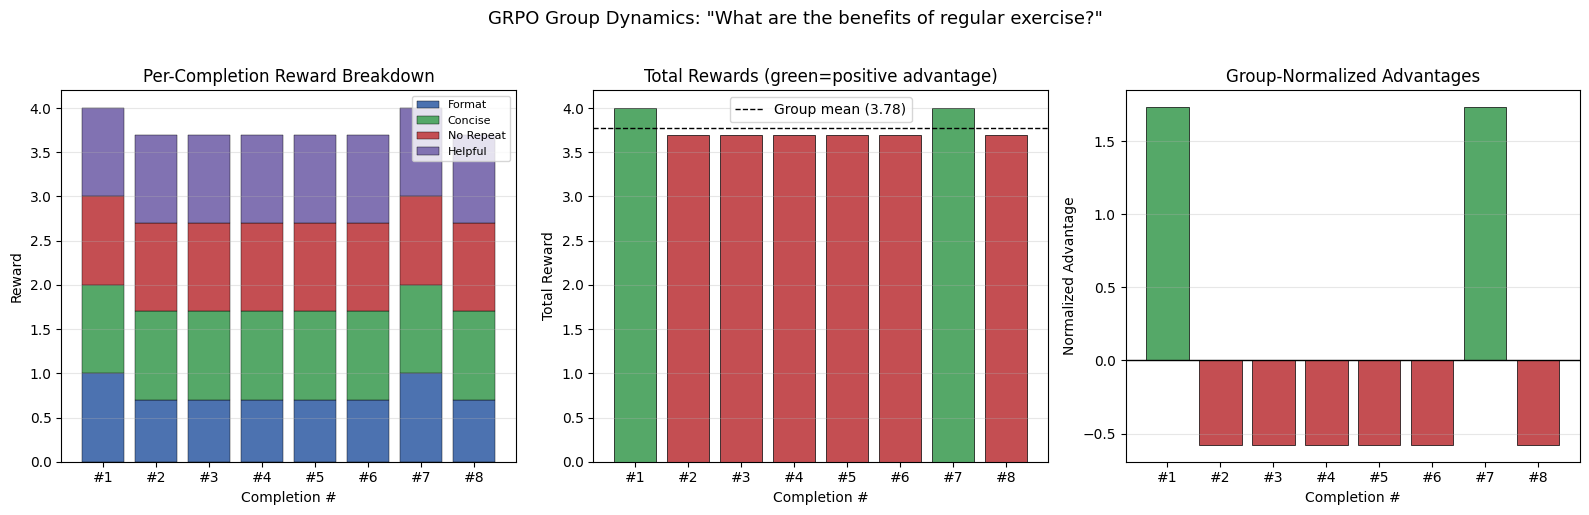

In [15]:
# Visualize the group scoring
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Stacked reward breakdown per completion
x = np.arange(GROUP_SIZE)
bottom = np.zeros(GROUP_SIZE)
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for idx, (key, color) in enumerate(zip(scores.keys(), colors)):
    vals = np.array(scores[key])
    axes[0].bar(x, vals, bottom=bottom, label=key.replace("_", " ").title(),
                color=color, edgecolor="black", linewidth=0.3)
    bottom += vals

axes[0].set_xlabel("Completion #")
axes[0].set_ylabel("Reward")
axes[0].set_title("Per-Completion Reward Breakdown")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"#{i+1}" for i in range(GROUP_SIZE)])
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

# Total reward distribution
bar_colors = ["#55A868" if a > 0 else "#C44E52" for a in advantages]
axes[1].bar(x, total_rewards, color=bar_colors, edgecolor="black", linewidth=0.5)
axes[1].axhline(y=mean_r, color="black", linestyle="--", linewidth=1, label=f"Group mean ({mean_r:.2f})")
axes[1].set_xlabel("Completion #")
axes[1].set_ylabel("Total Reward")
axes[1].set_title("Total Rewards (green=positive advantage)")
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"#{i+1}" for i in range(GROUP_SIZE)])
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

# Normalized advantages
axes[2].bar(x, advantages, color=bar_colors, edgecolor="black", linewidth=0.5)
axes[2].axhline(y=0, color="black", linewidth=1)
axes[2].set_xlabel("Completion #")
axes[2].set_ylabel("Normalized Advantage")
axes[2].set_title("Group-Normalized Advantages")
axes[2].set_xticks(x)
axes[2].set_xticklabels([f"#{i+1}" for i in range(GROUP_SIZE)])
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle(f'GRPO Group Dynamics: "{demo_prompt}"', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Cleanup
del demo_model
gc.collect()
torch.cuda.empty_cache()

## Using a Learned Reward Model with GRPO

While rule-based reward functions are powerful, GRPO also works with learned reward models. You can wrap the reward model from Notebook 04 as a reward function and pass it to `GRPOTrainer`.

Here is how you would do it (not executed to save VRAM):

```python
from transformers import AutoModelForSequenceClassification

reward_model = AutoModelForSequenceClassification.from_pretrained(
    "./results/reward_model/final",
    quantization_config=bnb_config,
    device_map="auto",
)
reward_tokenizer = AutoTokenizer.from_pretrained("./results/reward_model/final")


def learned_reward_func(prompts, completions, **kwargs):
    """Use the trained reward model to score completions."""
    rewards = []
    for prompt, completion in zip(prompts, completions):
        prompt_text = prompt[0]["content"] if isinstance(prompt, list) else prompt
        comp_text = completion[0]["content"] if isinstance(completion, list) else completion
        text = f"Prompt: {prompt_text}\nResponse: {comp_text}"
        inputs = reward_tokenizer(
            text, return_tensors="pt", truncation=True, max_length=512
        ).to(reward_model.device)
        with torch.no_grad():
            score = reward_model(**inputs).logits.squeeze().item()
        rewards.append(score)
    return rewards


# Then pass it to GRPOTrainer:
trainer = GRPOTrainer(
    model=model,
    reward_funcs=[learned_reward_func, format_reward_func],  # mix learned + rule-based
    ...
)
```

This combination — learned reward models for general quality plus rule-based functions for specific properties — is a common and effective pattern.

## Summary

### What We Covered

1. **GRPO algorithm** — Group-based advantage estimation eliminates the need for a value model, and reward functions replace the need for a pre-trained reward model.
2. **Rule-based reward functions** — We defined four reward functions (format, conciseness, no-repetition, helpfulness) to shape model behavior.
3. **Training** — Used TRL's `GRPOTrainer` to optimize Qwen2.5-7B-Instruct with QLoRA.
4. **Group dynamics** — Visualized how GRPO samples multiple completions per prompt and uses relative scoring to compute advantages.
5. **Comparison** — Evaluated the GRPO model against the base model on our reward metrics.

### Key Takeaways

- **Simpler than PPO**: No value model, no separate reward model training required. Two models in VRAM instead of four.
- **Flexible rewards**: Rule-based functions let you target specific behaviors precisely. You can iterate on reward functions without retraining a reward model.
- **Composable**: Mix and match rule-based and learned reward functions. Weight them with `reward_weights` in the config.
- **Practical for single-GPU**: The reduced memory footprint makes GRPO much more accessible than PPO for consumer hardware.

### GRPO in the Wild

GRPO gained prominence through DeepSeek's work:
- **DeepSeek-Math** (2024) introduced GRPO for mathematical reasoning
- **DeepSeek-R1** (2025) used GRPO as a core component of its training pipeline, achieving strong reasoning performance
- The open-source community has since adopted GRPO as a practical alternative to PPO, especially for domain-specific alignment tasks

### The Complete Alignment Toolkit

| Notebook | Method | Key Idea |
|----------|--------|----------|
| 03 | SFT | Learn from demonstrations |
| 04 | Reward Model | Learn human preferences |
| 05 | GRPO | RL with reward model (via GRPOTrainer) |
| 06 | DPO | Direct optimization on preference pairs |
| **08** | **GRPO** | **RL with group advantages + reward functions** |
| 09 | f-GRPO | Divergence-based RL with f-divergence variants |
| 10 | Final Evaluation | Comprehensive comparison of all models |